_Neural Data Science_

Lecturer: Prof. Dr. Philipp Berens, Dr. Jan Lause

Tutors: Jonas Beck, Kyra Kadhim, Jonathan Oesterle, Julius Würzler

Summer term 2026

Student names: Zhidong Zhang, Yuzhe Han, Bach Nguyen

LLM Disclaimer: Github Copilot was used to help with function calling and structure prompting, Claude and Gemini were used (by different members) to help with function understanding and outcome analysis.

# Coding Lab 2

## Introduction

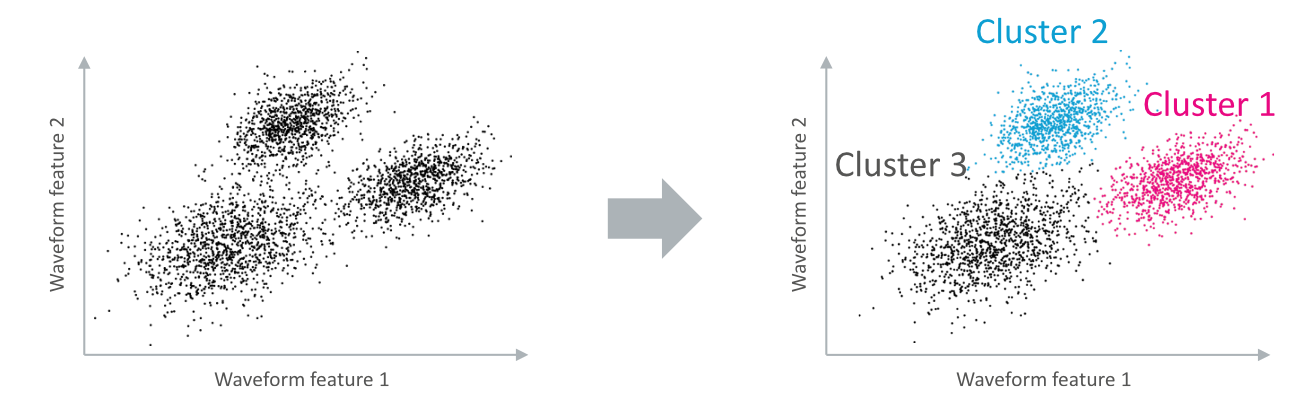

In this coding lab, we continue with the data from the first coding lab and finalize the Spike Sorting pipeline.
In particular, we use the created feature space to identify individual clusters by fitting a Gaussian Mixture Model.
To verify that this model does what we want, we first create a synthetic Toy Dataset and apply the model to that.

- __Data__: Use the saved data `nds_cl_1_*.npy` from Coding Lab 1. Or, if needed, download the data files ```nds_cl_1_*.npy``` from ILIAS and save it in the subfolder ```../data/```.
- __Dependencies__: You don't have to use the exact versions of all the dependencies in this notebook, as long as they are new enough. But if you run "Run All" in Jupyter and the boilerplate code breaks, you probably need to upgrade them.

In [ ]:
from __future__ import annotations
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

%load_ext jupyter_black

%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark -p sklearn

Last updated: 2026-05-02 21:07:11 CEST

Python implementation: CPython
Python version       : 3.10.0
IPython version      : 8.39.0

sklearn: 1.7.2

matplotlib: 3.10.8
numpy     : 2.2.6
scipy     : 1.15.3
sklearn   : 1.7.2

Watermark: 2.6.0



In [ ]:
plt.style.use("../matplotlib_style.txt")

## Load data

In [ ]:
# replace by path to your solutions
b = np.load("../data/nds_cl_1_features.npy")
s = np.load("../data/nds_cl_1_spiketimes_s.npy")
t = np.load("../data/nds_cl_1_spiketimes_t.npy")
w = np.load("../data/nds_cl_1_waveforms.npy")

## Task 1: Generate toy data

Sample 1000 data points from a two dimensional mixture of Gaussian model with three clusters  and the following parameters:

$\mu_1 = \begin{bmatrix}0\\0\end{bmatrix}, \Sigma_1 = \begin{bmatrix}1 & 0\\0 & 1\end{bmatrix}, \pi_1=0.3$

$\mu_2 = \begin{bmatrix}5\\1\end{bmatrix}, \Sigma_2 = \begin{bmatrix}2 & 1\\1 & 2\end{bmatrix}, \pi_2=0.5$

$\mu_3 = \begin{bmatrix}0\\4\end{bmatrix}, \Sigma_3 = \begin{bmatrix}1 & -0.5\\-0.5 & 1\end{bmatrix}, \pi_3=0.2$

Plot the sampled data points and indicate in color the cluster each point came from. Plot the cluster means as well.

*Grading: 2 pts*


In [ ]:
def sample_data(
    n_samples: int, m: np.ndarray, S: np.ndarray, p: np.ndarray, random_seed: int = 0
) -> tuple[np.ndarray, np.ndarray]:
    """Generate n_samples samples from a Mixture of Gaussian distribution with
    means m, covariances S and priors p.

    Parameters
    ----------

    n_samples: int
        Number of samples

    m: np.ndarray, (n_clusters, n_dims)
        Means

    S: np.ndarray, (n_clusters, n_dims, n_dims)
        Covariances

    p: np.ndarray, (n_clusters, )
        Cluster weights / probablities

    random_seed: int
        Random Seed

    Returns
    -------

    labels: np.array, (n_samples, )
        Grund truth labels.

    x: np.array, (n_samples, n_dims)
        Data points
    """
    # ensure reproducibility using a random number generator
    # hint: access random functions of this generator
    rng = np.random.default_rng(random_seed)
    n_cluster, n_dims = m.shape

    # ------------------------------------------------------
    # draw labeled points from mixture of Gaussians (1 pt)
    # ------------------------------------------------------
    labels = rng.choice(n_cluster, size=n_samples, p=p)

    x = np.zeros(shape=(n_samples, n_dims))
    for i in range(n_samples):
        k = labels[i]
        x[i] = rng.multivariate_normal(mean=m[k], cov=S[k])

    return labels, x

In [ ]:
N = 1000  # total number of samples

p = np.array([0.3, 0.5, 0.2])  # percentage of each cluster
m = np.array([[0.0, 0.0], [5.0, 1.0], [0.0, 4.0]])  # means

S1 = np.array([[1.0, 0.0], [0.0, 1.0]])
S2 = np.array([[2.0, 1.0], [1.0, 2.0]])
S3 = np.array([[1.0, -0.5], [-0.5, 1.0]])
S = np.stack([S1, S2, S3])  # cov

labels, x = sample_data(N, m, S, p)

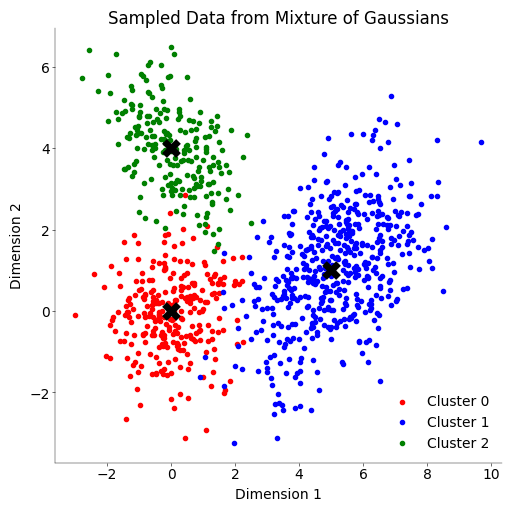

In [ ]:
# ----------------------------------------------
# plot points from mixture of Gaussians (1 pt)
# ----------------------------------------------

fig, ax = plt.subplots(figsize=(5, 5), layout="constrained")

colors = ["red", "blue", "green"]

for k in range(len(p)):
    ax.scatter(
        x[labels == k, 0], x[labels == k, 1], color=colors[k], label=f"Cluster {k}"
    )

ax.scatter(
    m[:, 0],
    m[:, 1],
    color="black",
    marker="X",
    s=180,
    linewidths=0.05,
    # label="Means",
)
plt.title("Sampled Data from Mixture of Gaussians")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.show()

## Task 2: Implement a Gaussian mixture model

Implement the EM algorithm to fit a Gaussian mixture model in `fit_mog()`.  Sort the data points by inferring their class labels from your mixture model (by using maximum a-posteriori classification). Fix the seed of the random number generator to ensure deterministic and reproducible behavior. Test it on the toy dataset specifying the correct number of clusters and make sure the code works correctly. Plot the data points from the toy dataset and indicate in color the cluster each point was assigned to by your model. How does the assignment compare to ground truth? If you run the algorithm multiple times, you will notice that some solutions provide suboptimal clustering solutions - depending on your initialization strategy.  

*Grading: 6 pts*


In [ ]:
a = np.array([[0, 2], [1, 1], [2, 0]]).T
print(a.shape)

np.cov(a, rowvar=False).shape

(2, 3)


(3, 3)

In [ ]:
def fit_mog(
    x: np.ndarray,
    n_clusters: int,
    n_iters: int = 10,
    random_seed: int = 0,
    init: str = "random",
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Fit Mixture of Gaussian model using EM algo.

    Parameters
    ----------

    x: np.array, (n_samples, n_dims)
        Input data

    n_clusters: int
        Number of clusters

    n_iters: int
        Maximal number of iterations.

    random_seed: int
        Random Seed


    Returns
    -------

    labels: np.array, (n_samples)
        Cluster labels

    m: list or np.array, (n_clusters, n_dims)
        Means

    S: list or np.array, (n_clusters, n_dims, n_dims)
        Covariances

    p: list or np.array, (n_clusters, )
        Cluster weights / probablities
    """
    # ensure reproducibility using a random number generator
    rng = np.random.default_rng(random_seed)

    # -----------
    # init (1 pt)
    # -----------
    n_samples, n_dims = x.shape
    reg_cov = np.eye(n_dims) * 1e-4  # to ensure the Covariance is positive definite

    if init == "kmeans":
        kmeans = KMeans(
            n_clusters=n_clusters,
            random_state=random_seed,
        ).fit(x)
        labels = kmeans.labels_
        m = kmeans.cluster_centers_.copy()  # mean
        S = np.array([np.cov(x, rowvar=False) + reg_cov for _ in range(n_clusters)])
        p = np.ones(shape=(n_clusters)) / n_clusters  # prior

    elif init == "random":
        indices = rng.choice(n_samples, size=n_clusters, replace=False)
        m = x[indices].copy()  # mean (n_clusters, n_dims)

        S = np.array([np.cov(x, rowvar=False) + reg_cov for _ in range(n_clusters)])

        p = rng.random(n_clusters)
        p = p / p.sum()

        labels = np.zeros(n_samples, dtype=int)

    # -------------------------
    # EM maximisation (3 pts)
    # -------------------------

    for step in range(n_iters):
        # E step
        # Evaluate the posterior probablibities `r`
        # using the current values of `m` and `S`

        r = np.zeros(shape=(n_samples, n_clusters))  # posterior (n_samples, n_clusters)

        ln_weighted_probs = np.zeros(
            shape=(n_samples, n_clusters)
        )  # (n_samples, n_clusters)
        for k in range(n_clusters):
            ln_likelihood_k = sp.stats.multivariate_normal.logpdf(
                x, mean=m[k], cov=S[k], allow_singular=True
            )  # (n_samples, )
            ln_prior = np.log(p[k] + 1e-300)  # scalar
            ln_weighted_probs[:, k] = ln_likelihood_k + ln_prior  # (n_samples, )

        ln_evidence = sp.special.logsumexp(ln_weighted_probs, axis=1)  # (n_samples, )
        r = np.exp(
            ln_weighted_probs - ln_evidence[:, np.newaxis]
        )  # (n_samples, n_clusters)

        labels = np.argmax(r, axis=1)  # (n_samples, )

        # M step
        # Estimate new `m`, `S` and `p`

        p = np.mean(r, axis=0)

        for k in range(n_clusters):
            rk_sum = r[:, k].sum()
            m[k] = np.sum(r[:, k][:, np.newaxis] * x, axis=0) / rk_sum
            diff = x - m[k]  # (n_samples, n_dims)
            weighted_diff = r[:, k][:, np.newaxis] * diff  # (n_samples, n_dims)
            S[k] = (weighted_diff.T @ diff) / rk_sum + reg_cov

    return labels, m, S, p

Run Mixture of Gaussian on toy data

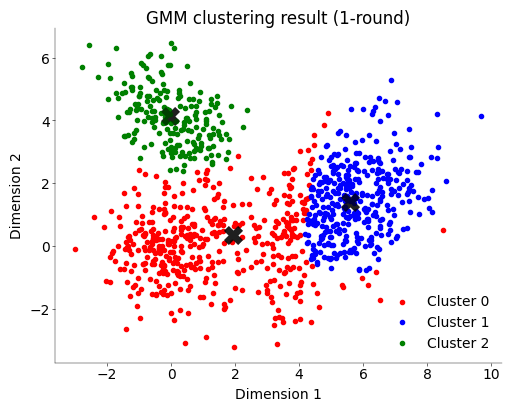

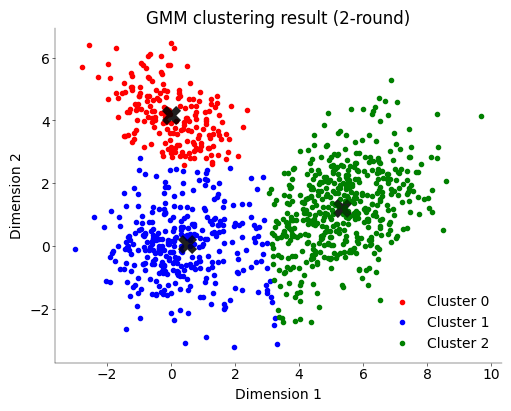

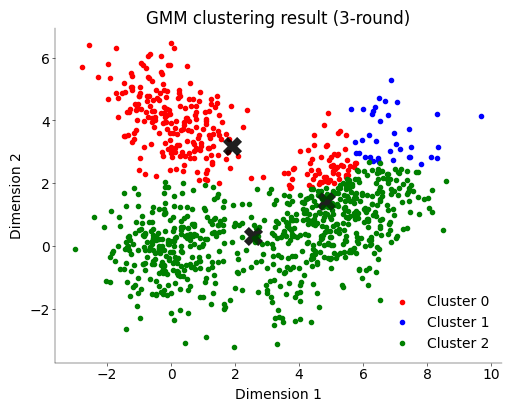

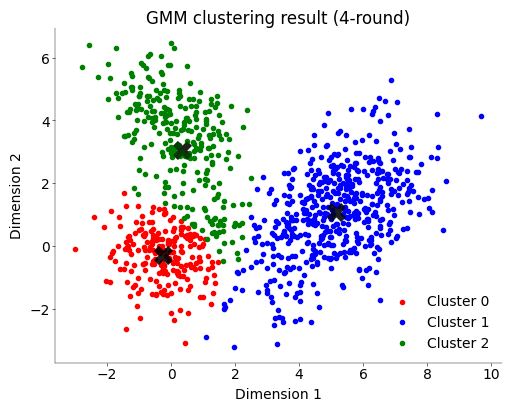

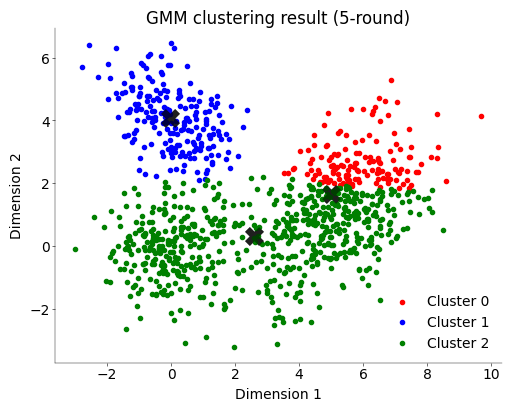

In [ ]:
# -------------------------------------------------------------------------
# Run the algorithm with 5 random inits on the toy data, plot and compare original and
# assigned clusters and answer the questions (1+1 pts)
# -------------------------------------------------------------------------
for i in range(1, 6):
    labels, m, S, p = fit_mog(x, n_clusters=3, random_seed=i, init="random")

    fig, ax = plt.subplots(figsize=(5, 4), layout="constrained")
    for k in range(3):
        ax.scatter(
            x[labels == k, 0], x[labels == k, 1], color=colors[k], label=f"Cluster {k}"
        )
        ax.scatter(
            m[:, 0],
            m[:, 1],
            color="black",
            marker="X",
            s=180,
            linewidths=0.05,
            alpha=0.5,
            # label="Means",
        )
    plt.title(f"GMM clustering result ({i}-round)")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.legend()
    plt.show()

### Questions

1) Do all runs converge to good solutions? If not, what are possible failure cases and how does the initialisation help?

No. Only the 2nd (and maybe 4th) round reach a good solution close enough to the ground truth. Other failure cases are mostly because the bad intialization of the mean centers, therefore a good intialization, by K-means for example, can help to prevent converging to local optima.

2) Do you get the same colors (=labels) in your best assignment(s) compared to the groundtruth? Does it have to be that way or not? Why?

It is unnecessary to link specific colors to specific clusters, as colors are merely for visualization and carry no intrinsic meaning

## Bonus Task (Optional): Mixture of drifting t-distributions

Instead of a simple Gaussian Mixture Model, more advanced algorithms can be implemented.
Implement a basic version of the mixture of drifting t-distributions (follow https://github.com/aecker/moksm/blob/master/MoT_Kalman.pdf).
What is the advantage of that method? You can verify your implementation using toy data, and then try to run it on the dataset below.

_Grading: 2 BONUS Points._


_BONUS Points do not count for this individual coding lab, but sum up to 5% of your **overall coding lab grade**. There are 4 BONUS points across all coding labs._

In [ ]:
# YOUR CODE HERE

## Task 3: Model complexity
A priori we do not know how many neurons we recorded. Extend your algorithm with an automatic procedure to select the appropriate number of mixture components (clusters). Base your decision on the Bayesian Information Criterion:

$BIC = -2L+P \log N,$

where $L$ is the log-likelihood of the data under the best model, $P$ is the number of parameters of the model and $N$ is the number of data points. You want to minimize the quantity. Plot the BIC as a function of mixture components. What is the optimal number of clusters on the toy dataset?

You can also use the BIC to make your algorithm robust against suboptimal solutions due to local minima. Start the algorithm multiple times and pick the best solutions. You will notice that this depends a lot on which initialization strategy you use.

*Grading: 5 pts*



### Question (0.5 pts)

1) What is the number of parameters of the model? Explain your derivation?

$P = (K - 1) + KD + {K} \frac{D(D + 1)}{2}$, where $K$ and $D$ are the number of clusters and the dimension of data respecitvely.
- $K-1$: prior distribution $\pi_k$, minus 1 due to the constrantion $\sum_k\pi_k=1$.
- $K\times D$: the center means of each cluster
- $\frac{D(D+1)}{2}$: the diagonal ($D$) and top half parts of the covariance matrix ($\binom{D}{2} = \frac{D(D-1)}{2}$)

In [ ]:
def mog_bic(
    x: np.ndarray, m: np.ndarray, S: np.ndarray, p: np.ndarray
) -> tuple[float, float]:
    """Compute the BIC for a fitted Mixture of Gaussian model

    Parameters
    ----------

    x: np.array, (n_samples, n_dims)
        Input data

    m: np.array, (n_clusters, n_dims)
        Means

    S: np.array, (n_clusters, n_dims, n_dims)
        Covariances

    p: np.array, (n_clusters, )
        Cluster weights / probablities

    Return
    ------

    bic: float
        BIC

    LL: float
        Log Likelihood
    """

    # -------------------------
    # implement the BIC (1.5 pts)
    # -------------------------
    n_samples, n_dims = x.shape
    n_clusters = p.shape[0]

    # log-likelihood Sum_k log[p(x)], p(x) = Sum_k p(k)p(x|k)

    ln_weighted_probs = np.zeros(shape=(n_samples, n_clusters))
    for k in range(n_clusters):
        ln_likelihood_k = sp.stats.multivariate_normal.logpdf(x, mean=m[k], cov=S[k])
        ln_weighted_probs[:, k] = ln_likelihood_k + np.log(p[k] + 1e-5)

    ln_evidence = sp.special.logsumexp(ln_weighted_probs, axis=1)

    LL = np.sum(ln_evidence, axis=0)

    # change here
    # P = (n_clusters - 1) + n_clusters * n_dims + n_dims * (n_dims + 1) / 2
    P = (n_clusters - 1) + n_clusters * n_dims + n_clusters * n_dims * (n_dims + 1) / 2

    bic = -2 * LL + P * np.log(n_samples)

    return bic, LL

In [ ]:
# ----------------------------------------------------------------------------------------------------------------------
# Compute the BIC for mixture models with different numbers of clusters (e.g., 2 - 6). (0.5 pts)
# Make your _estimate of the BIC_ robust against local minima, regardless of the initialization strategy used (0.5 pts)
# ----------------------------------------------------------------------------------------------------------------------

K = np.arange(2, 7)
num_seeds = 10

BIC = np.zeros((num_seeds, len(K)), dtype=float)
LL = np.zeros((num_seeds, len(K)), dtype=float)

# run mog and BIC multiple times here
for seed in range(num_seeds):
    for n_k in K:
        labels, m, S, p = fit_mog(
            x, n_clusters=int(n_k), random_seed=seed, init="random"
        )  # TODO: hot to make it robust? K-mean intialization?
        bic, ll = mog_bic(x, m, S, p)
        BIC[seed, n_k - 2] = bic
        LL[seed, n_k - 2] = ll


# BIC and LL, with K-means intialization
BIC_kmeans = np.zeros((len(K)))
LL_kmeans = np.zeros((len(K)))

for n_k in K:
    labels, m, S, p = fit_mog(x, n_clusters=int(n_k), random_seed=0, init="kmeans")
    bic, ll = mog_bic(x, m, S, p)
    BIC_kmeans[n_k - 2] = bic
    LL_kmeans[n_k - 2] = ll

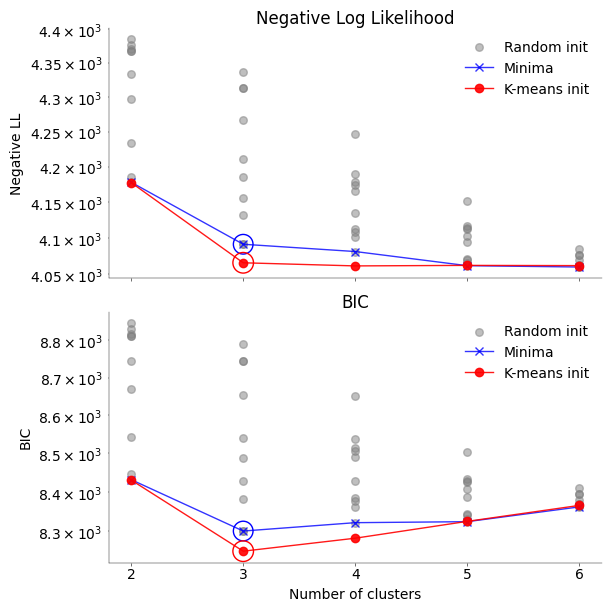

In [ ]:
# ------------------------------------------------------------------------------------------
# Plot the BIC over number of mixture components and highlight robust estimate and optimal number of clusters (0.5 pts)
# ------------------------------------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), sharex=True, layout="constrained")

# plot LL (random inits as points)
random_scatter1 = None
for i in range(LL.shape[0]):
    sc = ax1.scatter(
        K, -LL[i, :], alpha=0.5, marker="o", color="gray", s=30, label="_nolegend_"
    )
    if random_scatter1 is None:
        random_scatter1 = sc

minima_line = ax1.plot(
    K, -LL.max(axis=0), alpha=0.8, marker="x", color="blue", label="_nolegend_"
)
(kmeans_line,) = ax1.plot(
    K, -LL_kmeans, alpha=0.9, marker="o", color="red", label="_nolegend_"
)
ax1.set_yscale("log")
ax1.set_xticks(K)
ax1.set_xticklabels([str(int(k)) for k in K])
ax1.set_ylabel("Negative LL")
ax1.set_title("Negative Log Likelihood")
ax1.legend(
    [random_scatter1, minima_line[0], kmeans_line],
    ["Random init", "Minima", "K-means init"],
)

# plot BIC (random inits as points)
random_scatter2 = None
for i in range(BIC.shape[0]):
    sc2 = ax2.scatter(
        K, BIC[i, :], alpha=0.5, marker="o", color="gray", s=30, label="_nolegend_"
    )
    if random_scatter2 is None:
        random_scatter2 = sc2

minima_line2 = ax2.plot(
    K, BIC.min(axis=0), alpha=0.8, marker="x", color="blue", label="_nolegend_"
)
(kmeans_line2,) = ax2.plot(
    K, BIC_kmeans, alpha=0.9, marker="o", color="red", label="_nolegend_"
)

ax2.set_yscale("log")
ax2.set_ylabel("BIC")
ax2.set_title("BIC")
ax2.set_xlabel("Number of clusters")
ax2.legend(
    [random_scatter2, minima_line2[0], kmeans_line2],
    ["Random init", "Minima", "K-means init"],
)


# highlight chosen K (e.g., K=3) using k-means result
idx_k = np.where(K == 3)[0]
if idx_k.size:
    i = idx_k[0]
    ax1.scatter(
        K[i],
        -LL_kmeans[i],
        s=220,
        facecolors="none",
        marker="o",
        edgecolors="red",
        # linewidth=0.6,
        zorder=8,
    )
    ax2.scatter(
        K[i],
        BIC_kmeans[i],
        s=220,
        marker="o",
        facecolors="none",
        edgecolors="red",
        # linewidth=0.6,
        zorder=8,
    )
    # ax2.annotate(
    #     "K-means best",
    #     xy=(K[i], BIC_kmeans[i]),
    #     xytext=(K[i] + 0.6, np.nanmax(BIC_kmeans)),
    #     arrowprops=dict(arrowstyle="->", color="red"),
    #     color="red",
    # )

# highlight the lowest BIC across random inits (use hollow circle with same color)
seed_idx, k_idx = np.where(BIC == BIC.min())
if seed_idx.size:
    sidx = seed_idx[0]
    kidx = k_idx[0]
    ax1.scatter(
        K[kidx],
        -LL[sidx, kidx],
        s=200,
        facecolors="none",
        edgecolors="blue",
        marker="o",
        zorder=7,
    )
    ax2.scatter(
        K[kidx],
        BIC[sidx, kidx],
        s=200,
        facecolors="none",
        edgecolors="blue",
        marker="o",
        zorder=7,
    )
    # ax2.annotate(
    #     "Random best",
    #     xy=(K[kidx], BIC[sidx, kidx]),
    #     xytext=(
    #         K[kidx] + 0.6,
    #         BIC[sidx, kidx] + (np.nanmax(BIC) - np.nanmin(BIC)) * 0.05,
    #     ),
    #     arrowprops=dict(arrowstyle="->", color="blue"),
    #     color="blue",
    # )

plt.show()

### Questions

1) What happens to the BIC if the model got stuck in a local minimum? For your reasoning, you can also refer to Task 2.

As seen in Task 2, different random initializations can lead EM to different solutions. In a bad local optimum, some components may cover the same true cluster, while another true cluster may be missed, or one component may become almost empty.

The BIC would be larger if the model got stuck in a local minimum, because its suboptimal convergence leads to a smaller likelihood $L$, a larger negative likelihood $-L$, and finally a larger BIC $=-2L+ C$


2) The goal is to estimate which number of clusters best fits the data using the BIC. Therefore, what qualifies as a robust estimate? Explain your reasoning!

A robust estimate should correspond to the lowest BIC of the models given the numbder of clusters, i.e., the best result of models under that parameter. As local minima would enlarge the BIC, the robust estimate can be approximated by multiple random iterations, or use K-means for initialization while iterations to better avoid being stuck in local minima.

In this case, as shown above by the 'K-means init', the BIC reaches its bottom at $K=3$, aligned with the groundtruth. The lowest BIC obtained by 10 random runs, at $K=5$ fails to clearly show this pattern, but close, which implied the possibility of sufficient random runs reaching the real robust BIC even with a bad initialization. Overall, it is better to use a good initialization strategy and run multiple iterations to get a robust evaluation of the BIC.


## Task 4: Spike sorting using Mixture of Gaussian 
Run the full algorithm on your set of extracted features (MoG fitting + model complexity selection).

Show the plot of the BIC as a function of the number of mixture components on the real data, highlight the robust estimate and based on that the best number of clusters.

For the best model, make scatter plots of the first PCs on all four channels (6 plots). Color-code each data point according to its class label in the model with the optimal number of clusters. In addition, indicate the position (mean) of the clusters in your plot.

*Grading: 3 pts*


In [ ]:
# -------------------------------------------------------------
# Run the algorithm on the set of extracted features (0.5 pts)
# -------------------------------------------------------------

K = np.arange(2, 16)
num_seeds = 20

BIC = np.zeros((num_seeds, len(K)))
LL = np.zeros((num_seeds, len(K)))

# run mog and BIC multiple times here
for seed in range(num_seeds):
    for n_k in K:
        labels, m, S, p = fit_mog(
            b, n_clusters=int(n_k), random_seed=seed, init="kmeans"
        )
        bic, ll = mog_bic(b, m, S, p)
        BIC[seed, n_k - 2] = bic
        LL[seed, n_k - 2] = ll

# BIC and LL, with K-means intialization
BIC_kmeans = np.zeros((len(K)))
LL_kmeans = np.zeros((len(K)))

for n_k in K:
    labels, m, S, p = fit_mog(b, n_clusters=int(n_k), random_seed=0, init="kmeans")
    bic, ll = mog_bic(b, m, S, p)
    BIC_kmeans[n_k - 2] = bic
    LL_kmeans[n_k - 2] = ll

Best BIC: 2843137.55 at K=14 (seed=16)


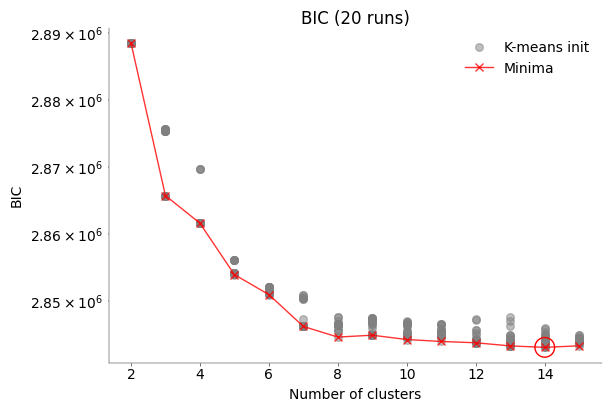

In [ ]:
# ----------------------------------------------------------------------------------------------------------------------
# Plot the BIC over number of mixture components and highlight robust estimate and optimal number of clusters (0.5 pts)
# ----------------------------------------------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 4))


random_kmeans_scatter = None
for i in range(BIC.shape[0]):
    sc = ax.scatter(
        K, BIC[i, :], alpha=0.5, marker="o", color="gray", s=30, label="_nolegend_"
    )
    if random_kmeans_scatter is None:
        random_kmeans_scatter = sc

minima_line = ax.plot(
    K, BIC.min(axis=0), alpha=0.8, marker="x", color="red", label="_nolegend_"
)
# (kmeans_line,) = ax.plot(
#     K, BIC_kmeans, alpha=0.9, marker="o", color="red", label="_nolegend_"
# )

ax.set_yscale("log")
ax.set_ylabel("BIC")
ax.set_title(f"BIC ({num_seeds} runs)")
# ax.set_xticklabels([str(int(k)) for k in K])
ax.set_xlabel("Number of clusters")
ax.legend(
    [random_kmeans_scatter, minima_line[0]],
    ["K-means init", "Minima"],
)

# highlight the lowest BIC across random inits (K-means)
seed_idx, k_idx = np.where(BIC == BIC.min())
if seed_idx.size:
    sidx = seed_idx[0]
    kidx = k_idx[0]
    ax.scatter(
        K[kidx],
        BIC[sidx, kidx],
        s=200,
        facecolors="none",
        edgecolors="red",
        marker="o",
        zorder=7,
    )
    print(f"Best BIC: {BIC[sidx, kidx]:.2f} at K={K[kidx]} (seed={sidx})")

# # highlight chosen K using k-means result
# idx_k = np.where(BIC_kmeans == BIC_kmeans.min())
# if idx_k:
#     i = idx_k[0]
#     ax.scatter(
#         K[i],
#         BIC_kmeans[i],
#         s=220,
#         marker="o",
#         facecolors="none",
#         edgecolors="red",
#         # linewidth=0.6,
#         zorder=8,
#     )

plt.show()

Refit model with lowest BIC and plot data points

In [ ]:
random_seed, kk = np.where(BIC == BIC.min())
random_seed = random_seed[0]
kk = kk[0]
print(f"lowest BIC: # cluster = {K[kk]}")
labels, m, S, p = fit_mog(b, K[kk], random_seed=random_seed, init="kmeans")  # refit

lowest BIC: # cluster = 14


Text(0.5, 0.98, 'Pairwise 1st PCs')

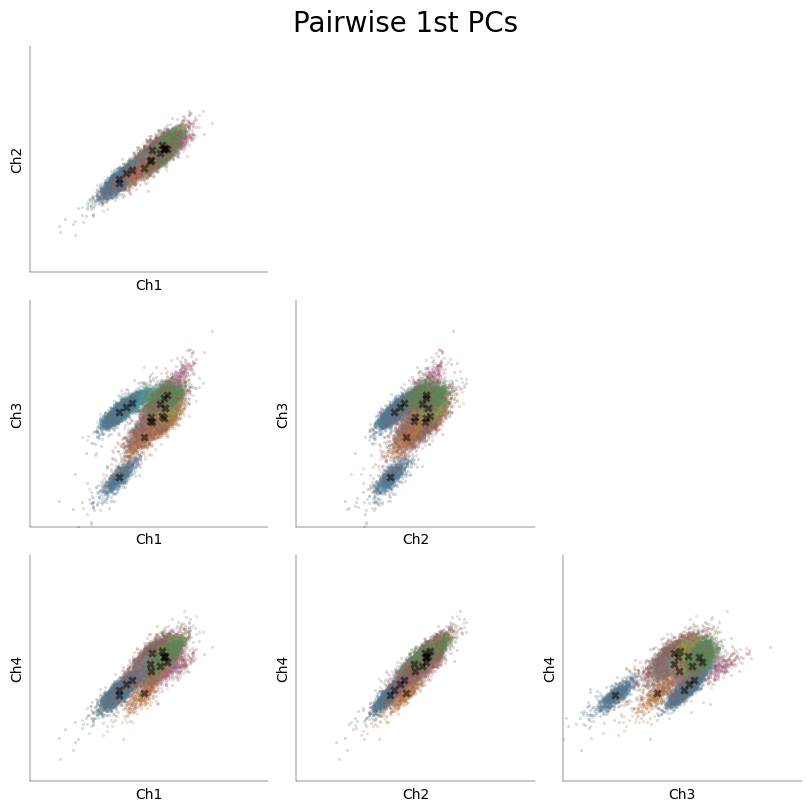

In [ ]:
# ------------------------------------------------------------------------------------------------------------------
# Create scatterplots of the first PCs under the best model for all pairwise combinations of the 4 channels. (1 pt)
# ------------------------------------------------------------------------------------------------------------------

mosaic = [
    ["Ch2 vs Ch1", ".", "."],
    ["Ch3 vs Ch1", "Ch3 vs Ch2", "."],
    ["Ch4 vs Ch1", "Ch4 vs Ch2", "Ch4 vs Ch3"],
]
fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(8, 8), layout="constrained", dpi=100
)

# index of the 1st PC in `b`
i = {"Ch1": 0, "Ch2": 3, "Ch3": 6, "Ch4": 9}

for mo in np.ravel(mosaic):
    if mo == ".":
        continue
    y, x = mo.split(" vs ")

    ax[mo].set_xlabel(x)
    ax[mo].set_ylabel(y)
    ax[mo].set_xlim((-1500, 1500))
    ax[mo].set_ylim((-1500, 1500))
    ax[mo].set_xticks([])
    ax[mo].set_yticks([])

    # Add data
    for k in range(K[kk]):
        ax[mo].scatter(
            b[labels == k, i[x]],
            b[labels == k, i[y]],
            alpha=0.2,
            s=3,
            marker="o",
            edgecolors="gray",
            linewidths=0.5,
            label=f"Cluster {k}",
        )

    # Plot cluster means (overlay as black X markers)
    ax[mo].scatter(
        m[:, i[x]],
        m[:, i[y]],
        marker="X",
        # s=1,
        c="black",
        # edgecolors="white",
        linewidths=0.02,
        zorder=5,
        alpha=0.5,
    )

# fig.legend()
fig.suptitle("Pairwise 1st PCs", fontsize=20)

## Task 5: Cluster separation and Correlograms

As postprocessing, implement the calculation of auto- and cross correlograms over the spike times.

Plot the (auto-/cross-) correlograms, displaying a time frame of -30ms to +30ms. Choose a good bin size and interprete the resulting diagrams.

_Grading: 3 pts_

#### Hints

_It is faster to calculate the histogram only over the spiketimes that are in the displayed range. Filter the spike times before calculating the histogram!_

_For the autocorrelogram, make sure not to include the time difference between a spike and itself (which would be exactly 0)_

_For the correlogram an efficient implementation is very important - looping over all spike times is not feasible. Instead, make use of numpy vectorization and broadcasting - you can use functions such as tile or repeat._

In [ ]:
# ----------------------------------------------------------------------
# Implement a function for calculating the spike time differences (1pt)
# ----------------------------------------------------------------------
def cross_time_diff(spiketimes1: np.ndarray, spiketimes2: np.ndarray) -> np.ndarray:
    """Compute the pairwise time differences between two sets of spike times.

    Parameters
    ----------
    spiketimes1: np.ndarray, (n_spikes1, )
        Spike times of the first cluster
    spiketimes2: np.ndarray, (n_spikes2, )
        Spike times of the second cluster

    Return
    ------

    time_diff: np.ndarray, (n_spikes1, n_spikes2)
        Pairwise time differences between the two sets of spike times
        (i.e., spiketimes1[i] - spiketimes2[j])
    """

    return spiketimes1[:, np.newaxis] - spiketimes2[np.newaxis, :]

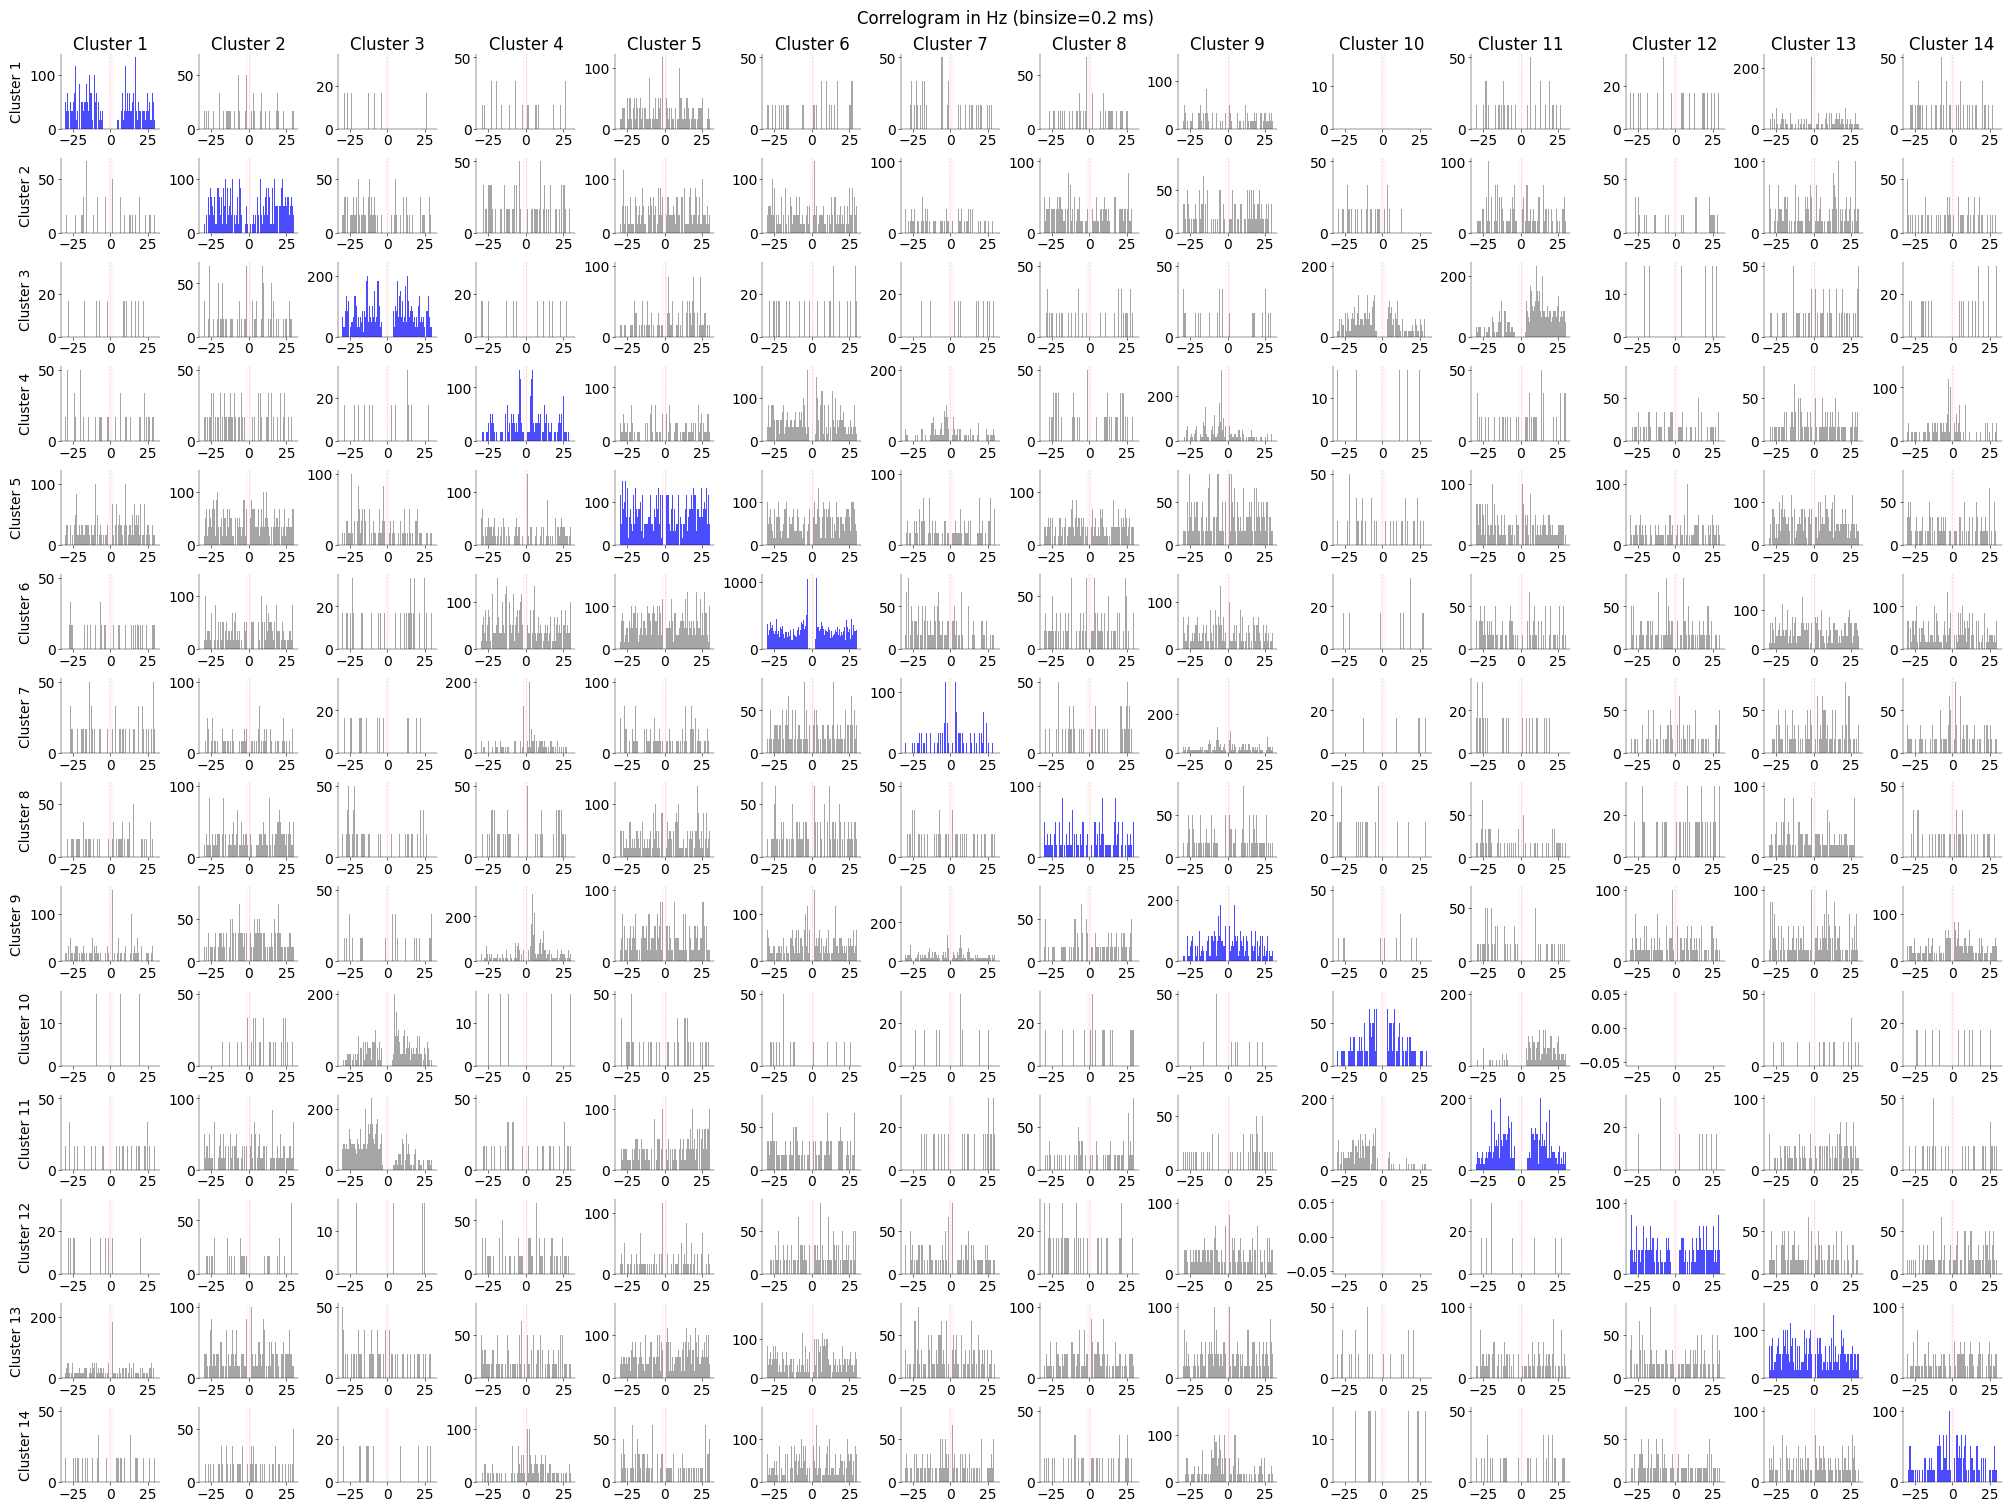

In [ ]:
# -----------------------------------------------------------------------------------
# Calculate and plot auto- and cross correlograms and answer the questions (1+1 pts)
# -----------------------------------------------------------------------------------
# t: spike time trains in ms (n_spikes)

t_spikes_clusters = [
    t[labels == cluster] for cluster in set(labels)
]  # time trains in ms for each cluster

n_clusters = len(t_spikes_clusters)
edg = 30  # ms
binsize = 0.2  # ms


def get_gca(data, edg, binsize):
    bins = np.arange(-edg, edg + binsize, binsize)
    counts, bin_edges = np.histogram(data, bins=bins)
    return counts, bin_edges


hist_clusters = {}

fig, axs = plt.subplots(
    n_clusters, n_clusters, figsize=(20, 15), constrained_layout=True
)

for i in range(n_clusters):
    for j in range(n_clusters):
        t_spike_i = t_spikes_clusters[i]
        t_spike_j = t_spikes_clusters[j]

        diffs_flat = cross_time_diff(t_spike_i, t_spike_j).flatten()  # flat to 1-d

        if i == j:  # auto-correlation
            diffs_flat = diffs_flat[diffs_flat != 0]
            ax_color = "blue"
        else:
            ax_color = "gray"

        # filter out diff outside the time frame
        diffs_flat = diffs_flat[np.abs(diffs_flat) <= 30]

        counts, bin_edges = get_gca(diffs_flat, edg, binsize)

        # plot
        ax = axs[i, j]
        ax.stairs(
            counts / (2 * edg / 1000), bin_edges, fill=True, color=ax_color, alpha=0.7
        )

        ax.axvline(0, color="red", linestyle="--", alpha=0.2, linewidth=0.5)
        # 1ms refractory period
        ax.axvline(-1, color="red", linestyle="--", alpha=1, linewidth=0.05)
        ax.axvline(1, color="red", linestyle="--", alpha=1, linewidth=0.05)

        if j == 0:
            ax.set_ylabel(f"Cluster {i+1}")
        if i == 0:
            ax.set_title(f"Cluster {j+1}")

plt.suptitle(f"Correlogram in Hz (binsize={binsize} ms)")
import os

# plt.savefig(os.path.join("..", "outputs", "Lab2_correlograms.png"))
plt.show()

### Questions
1) Based on the plot, do you see clusters that contain spikes likely from a single neuron?

**The clusters 1, 3, 6, 10, 11, 12** contain spikes likely from a single neuron, as they show a clear dip near $\tau=0$.

2) Do you see cases where plural clusters might come from the same neuron?

**The cluster 3, 10, 11** might come from the same neuron, as their crosscorelation shows a clear dip near $\tau=0$. They are not clear symmetric due to difference recording by different channels.

3) Do you see clusters that might contain spikes from plural neurons?

**The other clusters except for 1, 3, 6, 10, 11, 12** should contain spikes from plural neurons, as they don't show clear dip at the center.


4) Explain the term "refractory period" and how one can see it in this plot.

Refractory period refers to the time windows after a spike where the neuron cannot produce another spike, which lasts near 1ms. It is embodied by the dip around the center $\tau=0$ of the autocorrelation diagram.